In [1]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


Dataset loaded: 83,035 rows, 15 columns

Preparing features...
Features used: ['price', 'is_free', 'genre_encoded', 'avg_playtime_minutes', 'rating']
Samples after cleaning: 83,035

Train: 66,428 | Test: 16,607

MODEL 1: Linear Regression (Baseline)
RMSE : 2.0425
MAE  : 1.6164
R²   : 0.1276

Coefficients:
             Feature  Coefficient
               price     0.426148
avg_playtime_minutes     0.347048
             is_free    -0.181878
       genre_encoded     0.056435
              rating     0.000000

MODEL 2: Random Forest Regressor
RMSE : 1.6292
MAE  : 1.2985
R²   : 0.4449

Feature Importances:
             Feature  Importance
avg_playtime_minutes    0.862435
               price    0.098837
       genre_encoded    0.037426
             is_free    0.001303
              rating    0.000000


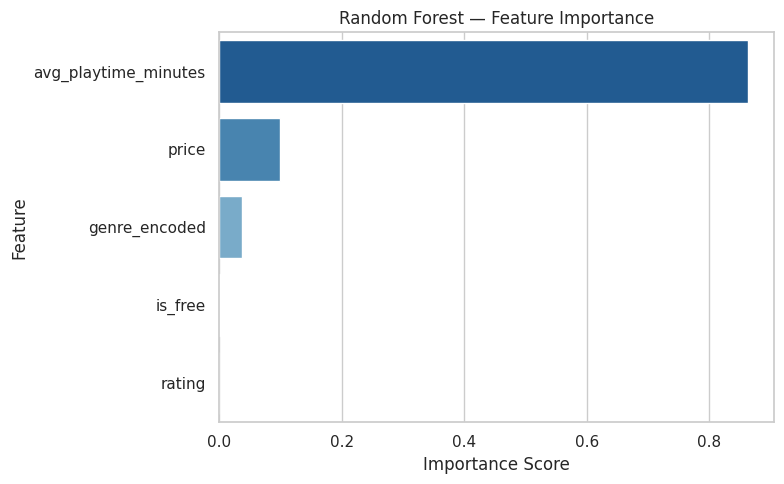

Saved: ml_feature_importance.png

MODEL COMPARISON SUMMARY
            Model     RMSE      MAE       R²
Linear Regression 2.042475 1.616383 0.127649
    Random Forest 1.629235 1.298548 0.444933


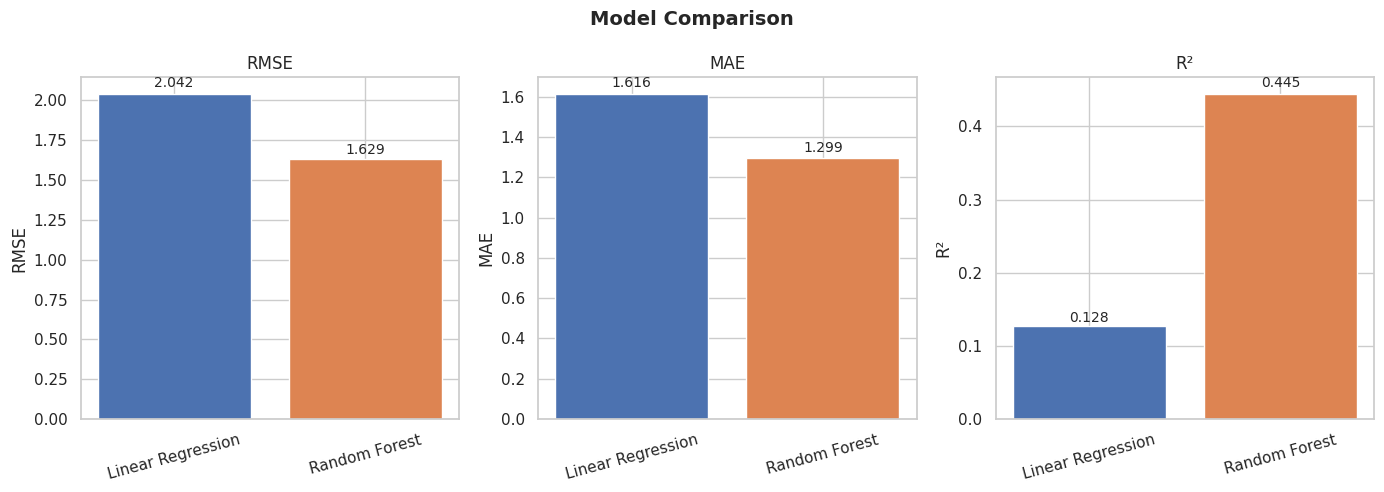

Saved: ml_model_comparison.png


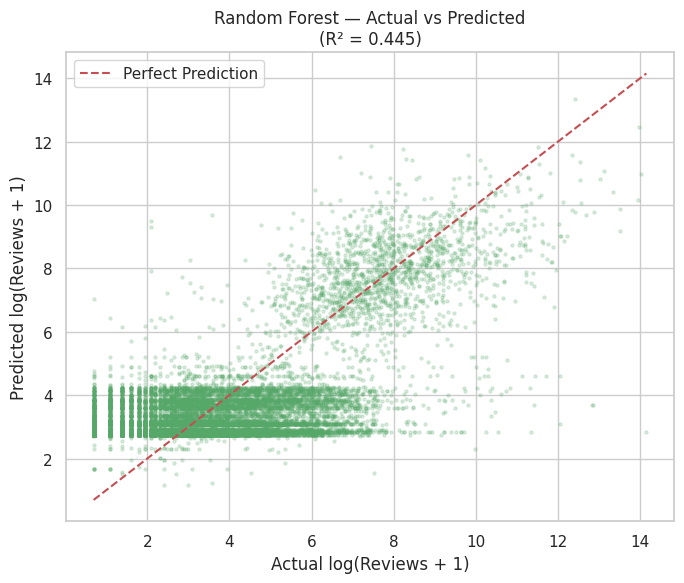

Saved: ml_actual_vs_predicted.png

MODEL 3: K-Means Clustering


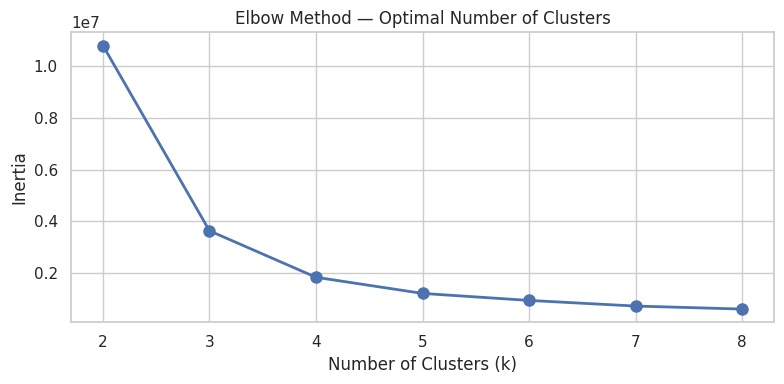

Saved: ml_elbow.png

K-Means with k=4:
         price  log_reviews
cluster                    
0         0.12         3.16
1        53.01         4.08
2        30.46         4.17
3        79.20         4.69


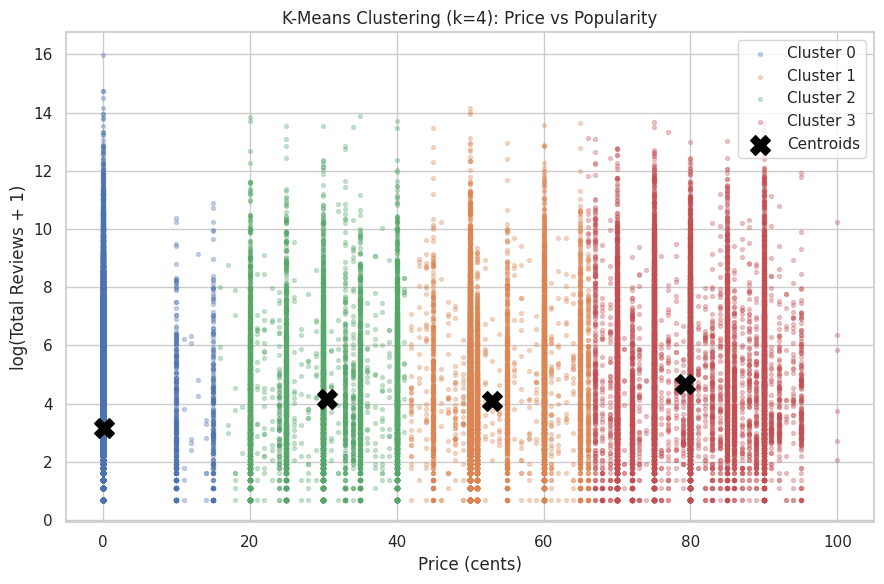

Saved: ml_clusters.png

Free vs Paid distribution per cluster:
cluster
0    0.99
1    0.00
2    0.00
3    0.00
Name: % Free Games, dtype: float64

MACHINE LEARNING SUMMARY
Model                     RMSE       MAE        R²
-------------------------------------------------------
Linear Regression         2.0425     1.6164     0.1276
Random Forest             1.6292     1.2985     0.4449
-------------------------------------------------------

Best model: Random Forest (highest R², lowest RMSE)

Most important feature: avg_playtime_minutes

K-Means identified 4 natural game clusters based on price and popularity.

Note: Target variable is log(total_reviews + 1) to handle skewed distribution.


In [5]:
# ============================================================
# DSA210 - Video Game Popularity Analysis
# Machine Learning
#
# Research Question:
# How do pricing and ratings influence the popularity of video games?
#
# Models:
# 1. Linear Regression       — baseline model
# 2. Random Forest Regressor — main predictive model
# 3. K-Means Clustering      — unsupervised grouping of games
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv("video_games_clean.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")


# ============================================================
# FEATURE ENGINEERING
# ============================================================
print("\nPreparing features...")

# Use log of total_reviews as target (reduces skewness)
df["log_reviews"] = np.log1p(df["total_reviews"])

# Extract primary genre (first genre listed)
df["primary_genre"] = df["genres"].fillna("Unknown").str.split(",").str[0].str.strip()

# Encode primary genre
le = LabelEncoder()
df["genre_encoded"] = le.fit_transform(df["primary_genre"])

# Select features
features = ["price", "is_free", "genre_encoded"]

# Add playtime if available
if "avg_playtime_minutes" in df.columns:
    df["avg_playtime_minutes"] = df["avg_playtime_minutes"].fillna(0)
    features.append("avg_playtime_minutes")

# Add rating if available
if "rating" in df.columns:
    df["rating"] = df["rating"].fillna(0)
    features.append("rating")

X = df[features].copy()
y = df["log_reviews"].copy()

# Drop rows with missing values
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"Features used: {features}")
print(f"Samples after cleaning: {X.shape[0]:,}")


# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Scale features (needed for Linear/Ridge Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# MODEL 1: LINEAR REGRESSION (Baseline)
# ============================================================
print("\n" + "="*60)
print("MODEL 1: Linear Regression (Baseline)")
print("="*60)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

# Coefficients
coef_df = pd.DataFrame({"Feature": features, "Coefficient": lr.coef_})
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)
print("\nCoefficients:")
print(coef_df.to_string(index=False))


# ============================================================
# MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================
print("\n" + "="*60)
print("MODEL 2: Random Forest Regressor")
print("="*60)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

# Feature importance plot
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="Blues_r")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("ml_feature_importance.png", dpi=150)
plt.show()
print("Saved: ml_feature_importance.png")


# ============================================================
# MODEL COMPARISON
# ============================================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R²": [r2_lr, r2_rf]
})
print(results.to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["RMSE", "MAE", "R²"]
colors = ["#4C72B0", "#DD8452"]

for i, metric in enumerate(metrics):
    vals = results[metric].values
    bars = axes[i].bar(results["Model"], vals, color=colors, edgecolor="white")
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + abs(bar.get_height()) * 0.01,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("ml_model_comparison.png", dpi=150)
plt.show()
print("Saved: ml_model_comparison.png")


# ============================================================
# ACTUAL vs PREDICTED PLOT (Random Forest)
# ============================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=5, color="#55A868")
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect Prediction")
plt.title(f"Random Forest — Actual vs Predicted\n(R² = {r2_rf:.3f})")
plt.xlabel("Actual log(Reviews + 1)")
plt.ylabel("Predicted log(Reviews + 1)")
plt.legend()
plt.tight_layout()
plt.savefig("ml_actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: ml_actual_vs_predicted.png")


# ============================================================
# MODEL 3: K-MEANS CLUSTERING
# ============================================================
print("\n" + "="*60)
print("MODEL 3: K-Means Clustering")
print("="*60)

# Use price and log_reviews for clustering
cluster_df = df[["price", "log_reviews", "is_free"]].dropna().copy()
cluster_features = cluster_df[["price", "log_reviews"]].values

# Elbow method to find optimal k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("ml_elbow.png", dpi=150)
plt.show()
print("Saved: ml_elbow.png")

# Fit K-Means with k=4
k_optimal = 4
km = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_df["cluster"] = km.fit_predict(cluster_features)

print(f"\nK-Means with k={k_optimal}:")
print(cluster_df.groupby("cluster")[["price", "log_reviews"]].mean().round(2))

# Cluster visualization
plt.figure(figsize=(9, 6))
colors_cluster = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
cluster_labels = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
}

for cluster_id in range(k_optimal):
    subset = cluster_df[cluster_df["cluster"] == cluster_id]
    plt.scatter(subset["price"], subset["log_reviews"],
                alpha=0.3, s=8,
                color=colors_cluster[cluster_id],
                label=cluster_labels[cluster_id])

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c="black", marker="X", zorder=5, label="Centroids")
plt.title(f"K-Means Clustering (k={k_optimal}): Price vs Popularity")
plt.xlabel("Price (cents)")
plt.ylabel("log(Total Reviews + 1)")
plt.legend()
plt.tight_layout()
plt.savefig("ml_clusters.png", dpi=150)
plt.show()
print("Saved: ml_clusters.png")

# Cluster composition (free vs paid)
print("\nFree vs Paid distribution per cluster:")
print(cluster_df.groupby("cluster")["is_free"].mean().round(2).rename("% Free Games"))


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("MACHINE LEARNING SUMMARY")
print("="*60)
print(f"{'Model':<25} {'RMSE':<10} {'MAE':<10} {'R²'}")
print("-"*55)
print(f"{'Linear Regression':<25} {rmse_lr:<10.4f} {mae_lr:<10.4f} {r2_lr:.4f}")
print(f"{'Random Forest':<25} {rmse_rf:<10.4f} {mae_rf:<10.4f} {r2_rf:.4f}")
print("-"*55)
print(f"\nBest model: Random Forest (highest R², lowest RMSE)")
print(f"\nMost important feature: {importance_df.iloc[0]['Feature']}")
print(f"\nK-Means identified {k_optimal} natural game clusters based on price and popularity.")
print("\nNote: Target variable is log(total_reviews + 1) to handle skewed distribution.")